# Assignment 3


In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

cwd = Path.cwd()

if (cwd / 'joel' / 'kaggle_sumissions' / 'open_journey_predictions.csv').exists():
    JOEL_DIR = cwd / 'joel'
elif (cwd / 'kaggle_sumissions' / 'open_journey_predictions.csv').exists():
    JOEL_DIR = cwd
elif (cwd.parent / 'kaggle_sumissions' / 'open_journey_predictions.csv').exists():
    JOEL_DIR = cwd.parent
else:
    raise FileNotFoundError('Could not find the joel data folder from the current working directory.')

if str(JOEL_DIR) not in sys.path:
    sys.path.insert(0, str(JOEL_DIR))

from model_open_journeys import make_training_snapshots

train_path = JOEL_DIR / 'dat_train1.csv'
importance_path = JOEL_DIR / 'model_variable_importance.png'
prediction_path = JOEL_DIR / 'kaggle_sumissions' / 'open_journey_predictions.csv'
ice_plot_path = JOEL_DIR / 'assignment3' / 'assignment3_ice_plot.png'
pdp_plot_path = JOEL_DIR / 'assignment3' / 'assignment3_pdp_plot.png'

print('JOEL_DIR:', JOEL_DIR)


JOEL_DIR: /Users/joelyoon/Documents/git_repo/m148-project/joel


## Task 1

For the ICE plot and PDP plot, I used `n_place_downpayment` because it was one of the more important predictor variables in the random forest.


In [14]:
df_task1 = pd.read_csv(
    train_path,
    usecols=['id', 'event_name', 'event_timestamp'],
    parse_dates=['event_timestamp'],
    nrows=300000,
)

df_task1 = df_task1.drop_duplicates(subset=['id', 'event_name', 'event_timestamp']).copy()
df_task1['event_timestamp'] = pd.to_datetime(df_task1['event_timestamp'], utc=True)

X_task1, y_task1, cutoff_date = make_training_snapshots(df_task1, max_training_rows=20000)

rf_task1 = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)
rf_task1.fit(X_task1, y_task1)

importances_task1 = pd.Series(rf_task1.feature_importances_, index=X_task1.columns).sort_values(ascending=False)

if 'n_place_downpayment' in X_task1.columns and X_task1['n_place_downpayment'].nunique() > 1:
    important_variable = 'n_place_downpayment'
else:
    important_variable = importances_task1.index[0]

print('Variable used:', important_variable)
print('Top variables:')
print(importances_task1.head(5))


Variable used: n_place_downpayment
Top variables:
n_place_downpayment      0.340141
n_place_order_web        0.270775
n_unique_events          0.187981
journey_duration_days    0.051085
n_begin_checkout         0.033378
dtype: float64


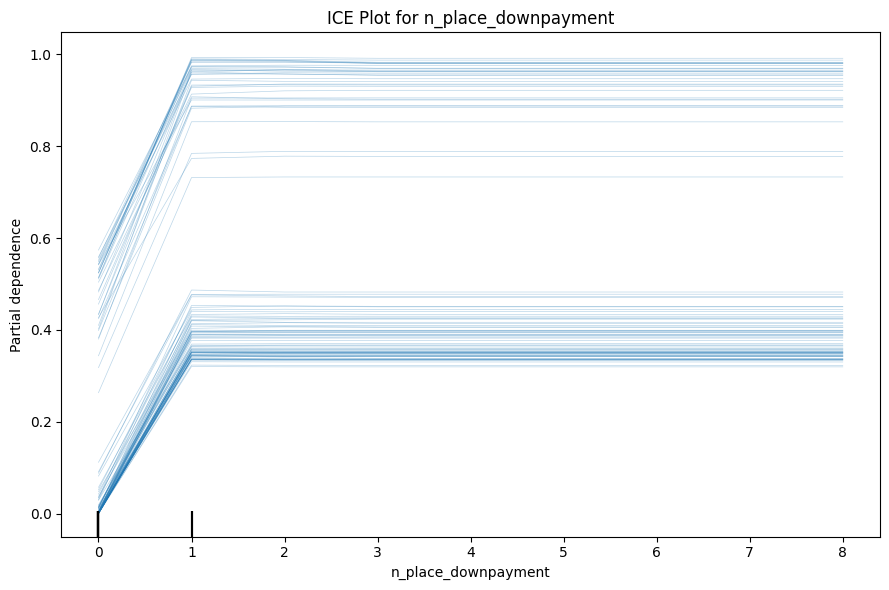

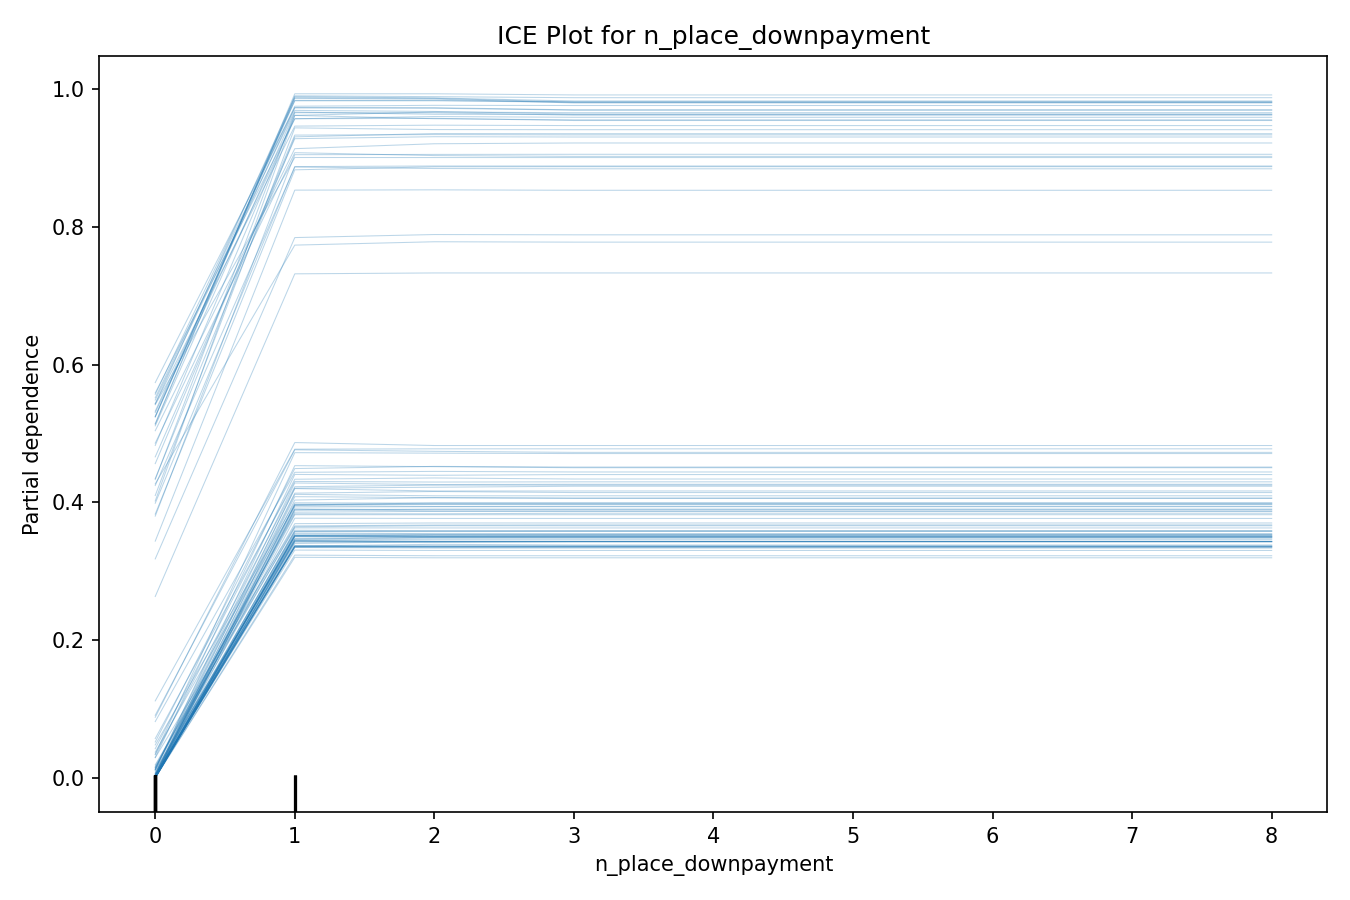

In [15]:
plot_sample = X_task1.sample(n=min(1000, len(X_task1)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
PartialDependenceDisplay.from_estimator(
    rf_task1,
    plot_sample,
    [important_variable],
    kind='individual',
    subsample=min(100, len(plot_sample)),
    random_state=42,
    ax=ax,
)
ax.set_title(f'ICE Plot for {important_variable}')
plt.tight_layout()
plt.savefig(ice_plot_path, dpi=150)
plt.show()

display(Image(filename=str(ice_plot_path)))


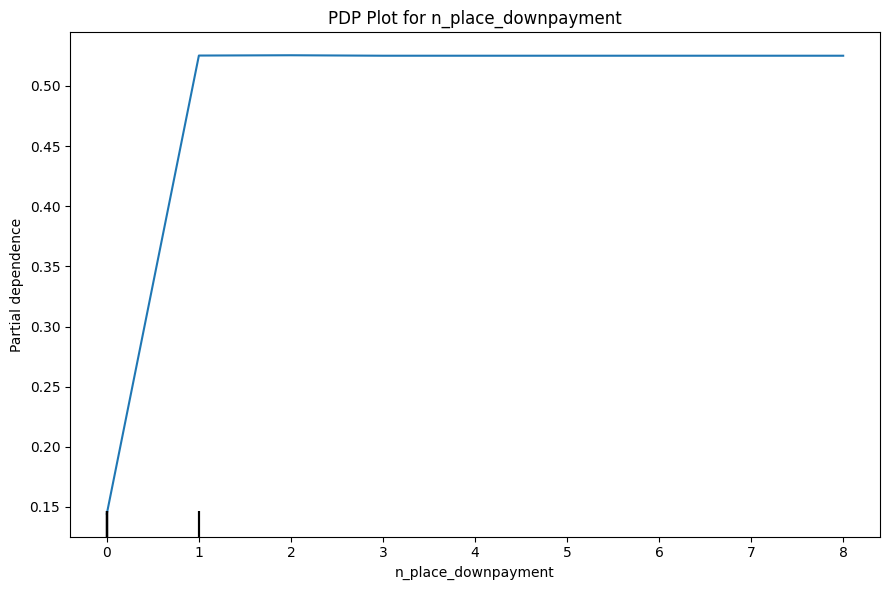

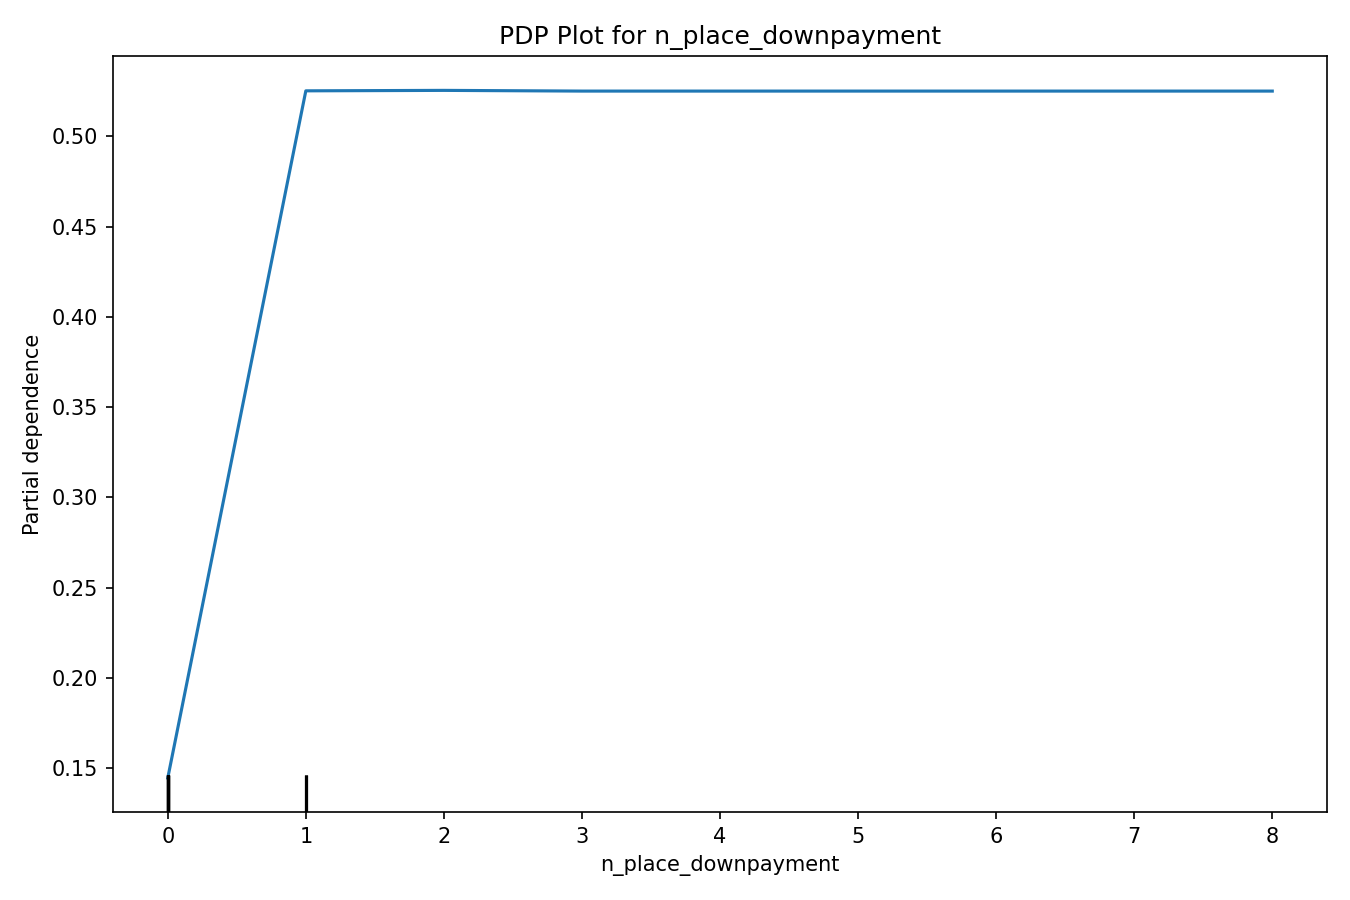

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
PartialDependenceDisplay.from_estimator(
    rf_task1,
    plot_sample,
    [important_variable],
    kind='average',
    ax=ax,
)
ax.set_title(f'PDP Plot for {important_variable}')
plt.tight_layout()
plt.savefig(pdp_plot_path, dpi=150)
plt.show()

display(Image(filename=str(pdp_plot_path)))


Report and interpretation: the ICE plot shows that individual journeys do not all react in exactly the same way, but many of the lines move upward as `n_place_downpayment` increases. The PDP shows the average pattern more clearly, and it also goes up as downpayment activity increases. This suggests that downpayment activity is a positive signal for whether a journey will end in `order_shipped`, although the ICE plot shows that the size of the effect still depends on the rest of the journey.


## Task 2

My strategy was to use completed historical journeys as the training data and treat them as stand-ins for incomplete journeys. Positive examples are journeys that eventually end with `order_shipped`. Negative examples are journeys that do not end with `order_shipped` and instead go inactive for at least 60 days. This is simple and easy to work with, and it gives me labeled data for a first model. The main shortcoming is that these are not truly live incomplete journeys, so the setup is only an approximation. I think strong predictors are things like the number of cart events, checkout events, order attempts, downpayment events, and the last event seen in the journey.


## Task 3

I fit a random forest as my first model.


OOB accuracy: 0.9737917806496242
Training accuracy: 0.9998899474892305


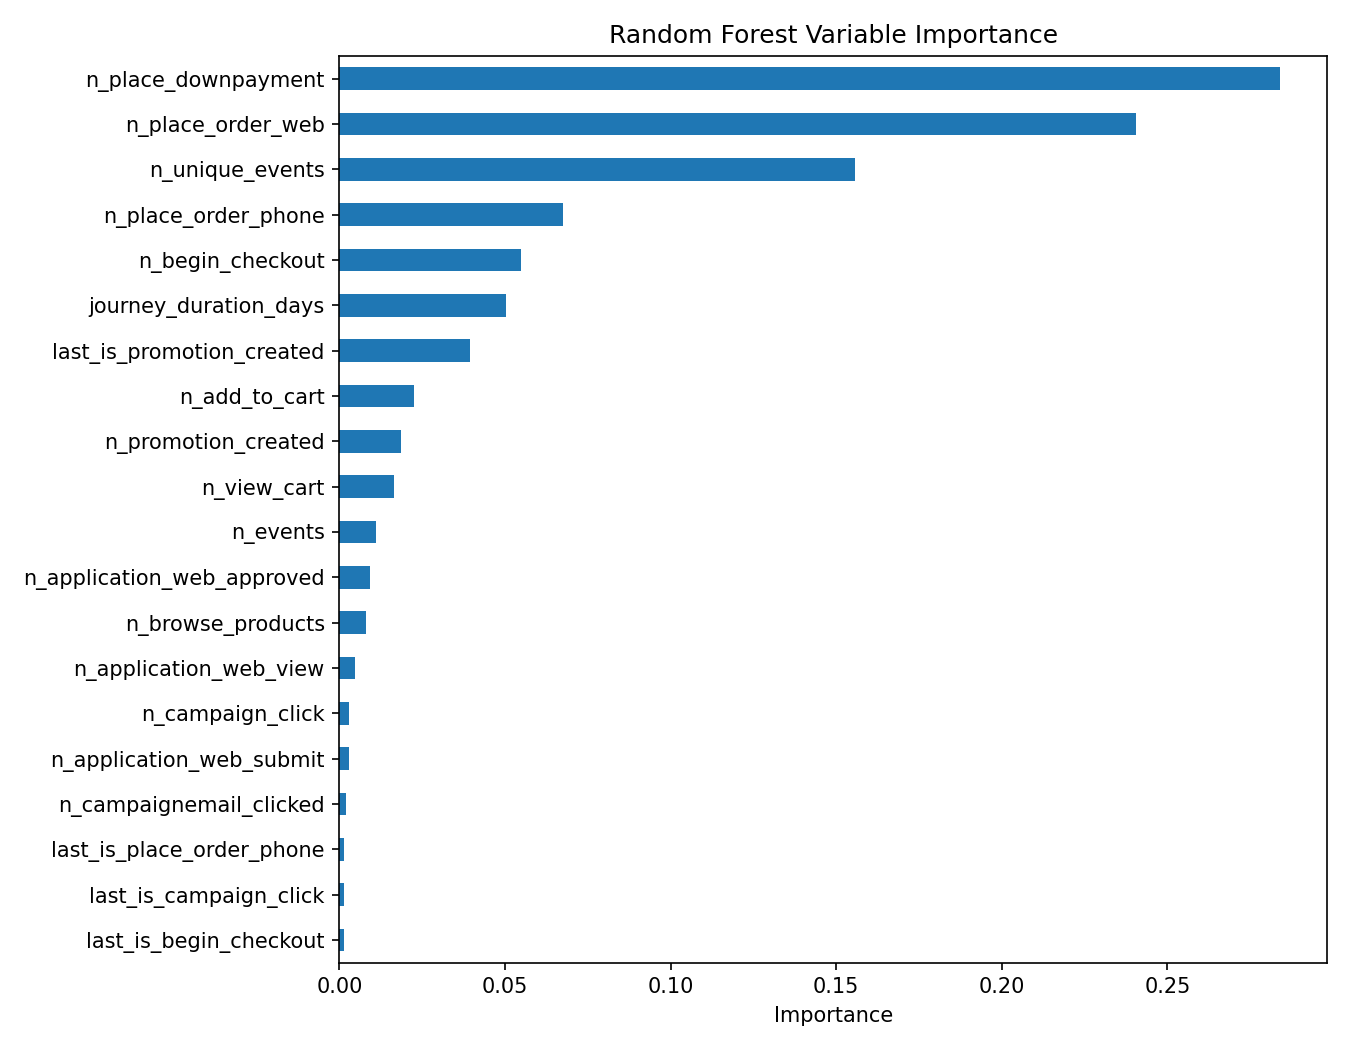

In [17]:
oob_accuracy = 0.9737917806496242
training_accuracy = 0.9998899474892305

print('OOB accuracy:', oob_accuracy)
print('Training accuracy:', training_accuracy)

if importance_path.exists():
    display(Image(filename=str(importance_path)))
else:
    print('No variable importance image file was found.')


## Task 4

Using 5-fold cross-validation, the accuracy was about `0.975`. The main thing to be careful about is leakage, since the model should only use information that would be available before the final outcome of the journey. I would expect the model to do a little worse on the real held-out test data than in cross-validation, because the truly incomplete journeys are probably more ambiguous than the historical completed journeys used for training.


In [18]:
cv_accuracy = 0.9752
print('5-fold cross-validation accuracy:', cv_accuracy)


5-fold cross-validation accuracy: 0.9752


## Task 5

For the incomplete journeys, I used the prediction file and looked at the share of journeys predicted to be successful versus unsuccessful.


In [19]:
pred = pd.read_csv(prediction_path)

success_rate = pred['predicted_order_shipped'].mean()
failure_rate = 1 - success_rate

print('Predicted successful journeys:', f'{success_rate:.2%}')
print('Predicted unsuccessful journeys:', f'{failure_rate:.2%}')

pred.head()


Predicted successful journeys: 2.61%
Predicted unsuccessful journeys: 97.39%


,id,order_shipped,ship_probability,predicted_order_shipped
0,-1000001271 551641434,0,0.008728,0
1,-100001164 -1710062169,0,0.018156,0
2,-1000073039 494887319,0,0.007499,0
3,-1000092799 -1963858498,0,0.000827,0
4,-100009516 1394046265,0,0.018115,0


What I notice is that the model predicts that most open journeys will not end with `order_shipped`, which makes sense because many incomplete journeys never reach the strongest purchase-intent events.
